In [3]:
# Forecasting model imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

In [5]:
# Load cleaned daily data
daily = pd.read_csv("../data/processed/daily_aggregated.csv")
daily["arrival_date"] = pd.to_datetime(daily["arrival_date"])

daily.head()

,arrival_date,daily_demand,avg_price,month,day_of_week,is_weekend
0,2015-07-01,100,95.368300,7,2,0
1,2015-07-02,36,99.188611,7,3,0
2,2015-07-03,37,99.524054,7,4,0
3,2015-07-04,44,90.669091,7,5,1
4,2015-07-05,37,107.966486,7,6,1


In [6]:
# Sort by time
daily = daily.sort_values("arrival_date")

# Use last 20% as test data
split_idx = int(len(daily) * 0.8)

train = daily.iloc[:split_idx]
test = daily.iloc[split_idx:]

In [7]:
# Prophet requires columns named ds (date) and y (target)
prophet_train = train.rename(
    columns={
        "arrival_date": "ds",
        "daily_demand": "y"
    }
)[["ds", "y"]]

In [8]:
# Initialize Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Fit model
model.fit(prophet_train)

18:12:10 - cmdstanpy - INFO - Chain [1] start processing
18:12:11 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
# Create future dataframe for entire time range
future = model.make_future_dataframe(periods=len(test))

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-07-01,66.548523,25.670483,95.392844,66.548523,66.548523,-6.979643,-6.979643,-6.979643,-3.545751,-3.545751,-3.545751,-3.433891,-3.433891,-3.433891,0.0,0.0,0.0,59.568881
1,2015-07-02,66.641433,31.658489,102.102174,66.641433,66.641433,-0.732109,-0.732109,-0.732109,3.911420,3.911420,3.911420,-4.643529,-4.643529,-4.643529,0.0,0.0,0.0,65.909324
2,2015-07-03,66.734343,36.111497,106.474684,66.734343,66.734343,3.783973,3.783973,3.783973,9.696666,9.696666,9.696666,-5.912693,-5.912693,-5.912693,0.0,0.0,0.0,70.518316
3,2015-07-04,66.827252,27.804953,96.690707,66.827252,66.827252,-4.962780,-4.962780,-4.962780,2.259669,2.259669,2.259669,-7.222449,-7.222449,-7.222449,0.0,0.0,0.0,61.864472
4,2015-07-05,66.920162,12.965229,84.720318,66.920162,66.920162,-19.484393,-19.484393,-19.484393,-10.932888,-10.932888,-10.932888,-8.551505,-8.551505,-8.551505,0.0,0.0,0.0,47.435769


In [10]:
# Merge predictions with actual demand
evaluation = daily.merge(
    forecast[["ds", "yhat"]],
    left_on="arrival_date",
    right_on="ds",
    how="left"
)

test_eval = evaluation.iloc[split_idx:]

mae = mean_absolute_error(test_eval["daily_demand"], test_eval["yhat"])
rmse = np.sqrt(mean_squared_error(test_eval["daily_demand"], test_eval["yhat"]))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 19.31
RMSE: 23.74


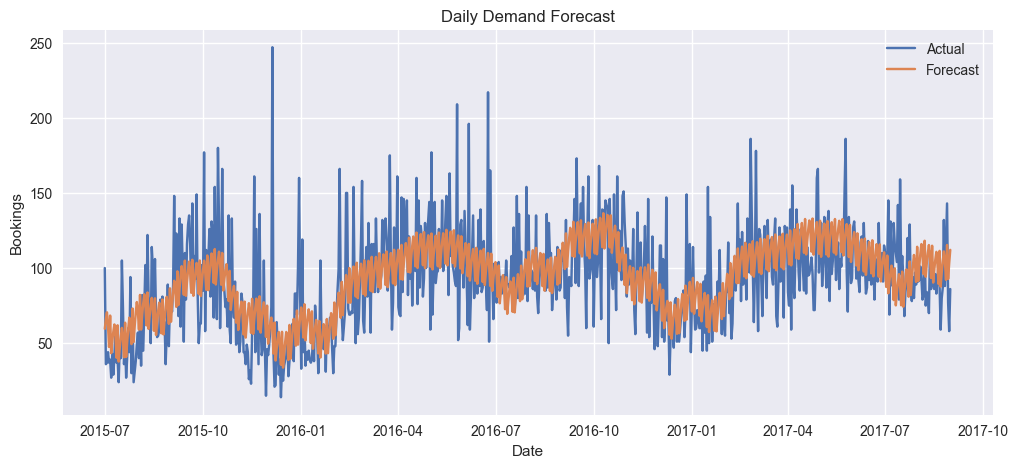

In [11]:
plt.figure(figsize=(12,5))
plt.plot(evaluation["arrival_date"], evaluation["daily_demand"], label="Actual")
plt.plot(evaluation["arrival_date"], evaluation["yhat"], label="Forecast")
plt.legend()
plt.title("Daily Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Bookings")
plt.show()

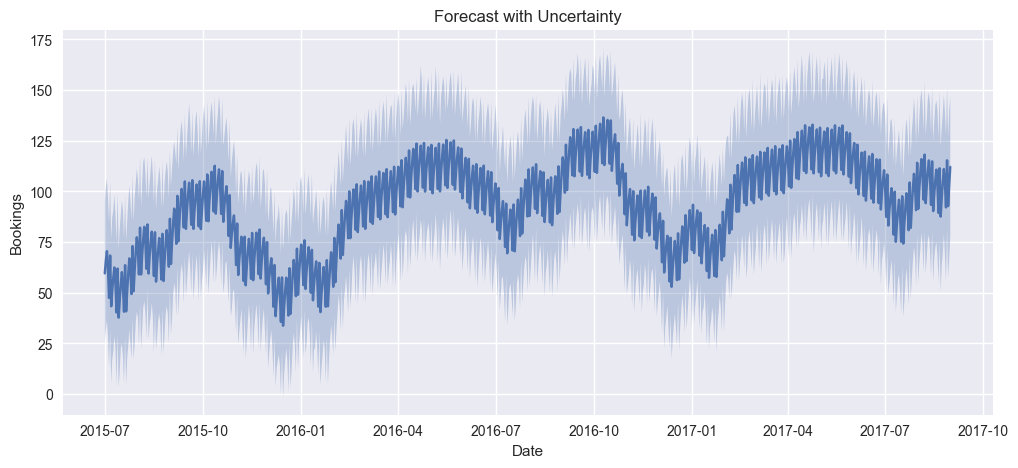

In [12]:
plt.figure(figsize=(12,5))
plt.plot(forecast["ds"], forecast["yhat"], label="Forecast")
plt.fill_between(
    forecast["ds"],
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    alpha=0.3
)
plt.title("Forecast with Uncertainty")
plt.xlabel("Date")
plt.ylabel("Bookings")
plt.show()

In [13]:
forecast.to_csv("../data/processed/forecast_output.csv", index=False)